# Model Development 1: Linear Regression

In [1]:
# Import libraries for data manipulation and visualization
import numpy as np 
import os
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
# Set the numbers of columns to be displayed in the output
pd.set_option('display.max_columns', None)

### Approach: Linear Regression

+ Data Preparation: splitting models into training and testing sets
+ Model Building: building simple and multivariate linear regression model from scratch 
+ Model Training: train the model with chosen number of datasamples
+ Model Evaluation: evaluate the performance of model with fixed paramters
+ Model Tuning with Hyperparamters: re-train and re-evaluate the model with hyperparamters

In [3]:
# Load the dataset from phase 3
path = "D:\Projectwork Platform\MEP-Machine-Learning\Laptop_Price_Prediction\dataset"
csv_file = os.path.join(path, "ebay_laptop_data_phase3.csv")
laptop_df = pd.read_csv(csv_file)
laptop_df.head()

<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mian_\AppData\Local\Temp\ipykernel_18072\3772760037.py:2: SyntaxWarning: invalid escape sequence '\P'
  path = "D:\Projectwork Platform\MEP-Machine-Learning\Laptop_Price_Prediction\dataset"


,Brand,Price,Color,GPU,Processor Speed,Display Width,Display Height,OS,Storage Type,Hard Drive Capacity,SSD Capacity,Screen Size (cm),Ram Size,Price per Screen Size,Price per Display Height,Price per Display Width,Bluetooth,Touchscreen,WiFi,Webcam
0,dell,400.00,black,intel,4.2,1920.0,1080.0,windows,ssd,2000.00,205.95,14.0,5.98,28.571429,0.370370,0.208333,Yes,No,Yes,Yes
1,dell,175.00,black,intel,2.4,1920.0,1080.0,windows,ssd,500.00,500.00,14.0,16.00,12.500000,0.162037,0.091146,Yes,Yes,Yes,Yes
2,hp,85.00,black,intel,2.4,1366.0,768.0,chrome,emmc,16.00,205.95,11.6,4.00,7.327586,0.110677,0.062225,Yes,No,Yes,Yes
3,dell,101.25,other,other,1.4,1366.0,768.0,windows,ssd,98.89,256.00,12.5,8.00,8.100000,0.131836,0.074122,No,No,Yes,Yes
4,acer,50.00,black,other,1.6,1366.0,768.0,chrome,ssd,98.89,16.00,11.6,4.00,4.310345,0.065104,0.036603,Yes,Yes,No,No


## Data Preparation

+ Data splitting: splitting into training and testing sets
+ Feature Scaling: scaling features using StandardScaling
+ Feature Encoding: encoding categorical features using label encoding


In [4]:
# import dependencies for preparing data 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [5]:
# Filter out irrelevant data
laptop_df = laptop_df.drop(columns=["Brand"], axis=1)

# Split the dataset into testing and training sets
laptopX = laptop_df.drop(columns=["Price"], axis=1)
laptopY = laptop_df["Price"]

xtrain, xtest, ytrain, ytest = train_test_split(laptopX, laptopY, test_size=0.2, random_state=42)
print(f"Training set: x={xtrain.shape}, y={ytrain.shape}")
print(f"Test set: x={xtest.shape}, y={ytest.shape}")

Training set: x=(1976, 18), y=(1976,)
Test set: x=(495, 18), y=(495,)


In [6]:
xtrain.head()

,Color,GPU,Processor Speed,Display Width,Display Height,OS,Storage Type,Hard Drive Capacity,SSD Capacity,Screen Size (cm),Ram Size,Price per Screen Size,Price per Display Height,Price per Display Width,Bluetooth,Touchscreen,WiFi,Webcam
1610,other,other,1.186174,779.242171,447.949319,unknown,unknown,98.89,205.95,9.076586,5.98,15.336162,0.310749,0.178635,No,No,No,No
1525,black,amd,4.300000,1920.000000,1080.000000,windows,ssd,2000.00,2000.00,15.600000,40.00,44.807692,0.647222,0.364063,Yes,No,No,Yes
2366,other,other,1.186174,779.242171,447.949319,unknown,unknown,98.89,205.95,9.076586,5.98,8.015128,0.162407,0.093360,No,No,No,No
859,black,intel,2.900000,1920.000000,1080.000000,windows,ssd,512.00,512.00,15.600000,16.00,21.089744,0.304630,0.171354,Yes,No,Yes,Yes
497,other,intel,2.100000,1600.000000,900.000000,windows,ssd,128.00,128.00,14.000000,8.00,32.414286,0.504222,0.283625,No,No,No,No


In [7]:
# Encode the categorical features
labelencoder = LabelEncoder()

for feature in xtrain.select_dtypes(include=["object"]).columns:
    xtrain[feature] = labelencoder.fit_transform(xtrain[feature]).reshape(-1, 1)
    xtest[feature] = labelencoder.fit_transform(xtest[feature]).reshape(-1, 1)

xtrain.head()

,Color,GPU,Processor Speed,Display Width,Display Height,OS,Storage Type,Hard Drive Capacity,SSD Capacity,Screen Size (cm),Ram Size,Price per Screen Size,Price per Display Height,Price per Display Width,Bluetooth,Touchscreen,WiFi,Webcam
1610,10,4,1.186174,779.242171,447.949319,3,4,98.89,205.95,9.076586,5.98,15.336162,0.310749,0.178635,0,0,0,0
1525,0,0,4.300000,1920.000000,1080.000000,4,3,2000.00,2000.00,15.600000,40.00,44.807692,0.647222,0.364063,1,0,0,1
2366,10,4,1.186174,779.242171,447.949319,3,4,98.89,205.95,9.076586,5.98,8.015128,0.162407,0.093360,0,0,0,0
859,0,1,2.900000,1920.000000,1080.000000,4,3,512.00,512.00,15.600000,16.00,21.089744,0.304630,0.171354,1,0,1,1
497,10,1,2.100000,1600.000000,900.000000,4,3,128.00,128.00,14.000000,8.00,32.414286,0.504222,0.283625,0,0,0,0


In [8]:
# Scale the feautre using standard scaler
scaler = StandardScaler()

# Scale input numerical features
for feature in xtrain.select_dtypes(include=[float]).columns:
    xtrain[feature] = scaler.fit_transform(xtrain[[feature]]).reshape(-1, 1)
    xtest[feature] = scaler.fit_transform(xtest[[feature]]).reshape(-1, 1)

print(ytrain[:5])
xtrain.head()

1610    139.20
1525    699.00
2366     72.75
859     329.00
497     453.80
Name: Price, dtype: float64


,Color,GPU,Processor Speed,Display Width,Display Height,OS,Storage Type,Hard Drive Capacity,SSD Capacity,Screen Size (cm),Ram Size,Price per Screen Size,Price per Display Height,Price per Display Width,Bluetooth,Touchscreen,WiFi,Webcam
1610,10,4,-1.042685,-1.084776,-1.035188,3,4,-0.360313,-0.355367,-0.128994,-0.183073,-0.326775,-0.199548,-0.194508,0,0,0,0
1525,0,0,2.641320,0.873101,0.763551,4,3,5.850545,4.143220,0.021391,0.889595,1.156756,0.832031,0.794273,1,0,0,1
2366,10,4,-1.042685,-1.084776,-1.035188,3,4,-0.360313,-0.355367,-0.128994,-0.183073,-0.695300,-0.654346,-0.649234,0,0,0,0
859,0,1,0.984963,0.873101,0.763551,4,3,0.989303,0.412055,0.021391,0.132863,-0.037153,-0.218310,-0.233334,1,0,1,1
497,10,1,0.038473,0.323887,0.251293,4,3,-0.265211,-0.550827,-0.015494,-0.119381,0.532899,0.393613,0.365345,0,0,0,0


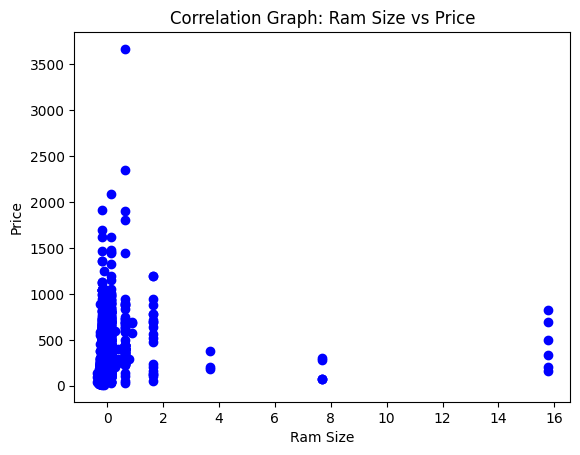

In [9]:
# Visualize the data distribution: target variable and features
def correlation_graph(x,y = "Price", dataX = xtrain, dataY = ytrain, color="blue"):
    feature = dataX[x]
    target = dataY

    plt.scatter(feature, target, color=color)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f"Correlation Graph: {x} vs {y}")
    plt.show()

correlation_graph("Ram Size")

## Model Building

In [10]:
# Import Linear regression model 
from linear_regression import SimpleLinearRegression

In [11]:
# Create a linear regression model 
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate 
        self.n_iters = n_iterations 
        self.weights = None 
        self.bias = None 
    
    def fit(self, X, y):
        # Initialize the weights and bias 
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Iterate through the number of iterations 
        for i in range(self.n_iters):
            # Compute the linear model 
            ypred = self.predict(X)

            # Compute gradients for weights and bias
            dW = (1/n_samples) * np.dot(X.T, (ypred - y))
            db = (1/n_samples) * np.sum(ypred - y)

            # Update weights and bias through Gradient Descent Algorithm
            self.weights = self.weights - self.lr * dW
            self.bias = self.bias - self.lr * db

            # Print the loss function
            loss = self.loss(y, ypred)
            print(f"Iteration {i + 1}: weights = {self.weights[:3]}, bias = {self.bias}, loss = {loss}")
        
        return self.weights, self.bias
    
    def loss(self, y, ypred):
        # Compute the loss function using Mean Sqauared Error (MSE)
        loss = np.mean((ypred - y)**2)
        return loss

    def predict(self, X):
        # Make predictions based on the x values
        ypred = np.dot(X, self.weights) + self.bias
        return ypred

In [12]:
# Select a feature for training the model
feature = "Price per Screen Size"

# Train the linear model using training set
lin_model = LinearRegression(learning_rate=0.001, n_iterations=1000)
lin_model.fit(xtrain[[feature]], ytrain)

Iteration 1: weights = [0.23894823], bias = 0.29566895748987854, loss = 156021.10141730768
Iteration 2: weights = [0.47765752], bias = 0.5910422460222673, loss = 155732.21315175734
Iteration 3: weights = [0.7161281], bias = 0.8861201612661236, loss = 155443.90237384985
Iteration 4: weights = [0.9543602], bias = 1.180902998594736, loss = 155156.16792918742
Iteration 5: weights = [1.19235408], bias = 1.4753910530860197, loss = 154869.0086656799
Iteration 6: weights = [1.43010996], bias = 1.7695846195228122, loss = 154582.42343354007
Iteration 7: weights = [1.66762808], bias = 2.063483992393168, loss = 154296.4110852793
Iteration 8: weights = [1.90490869], bias = 2.3570894658906534, loss = 154010.97047570272
Iteration 9: weights = [2.14195201], bias = 2.6504013339146413, loss = 153726.1004619047
Iteration 10: weights = [2.37875829], bias = 2.9434198900706052, loss = 153441.79990326418
Iteration 11: weights = [2.61532777], bias = 3.2361454276704134, loss = 153158.06766144047
Iteration 12: 

(array([151.08806162]), np.float64(186.95283457404932))

Weights: [151.08806162], Bias: 186.95283457404932


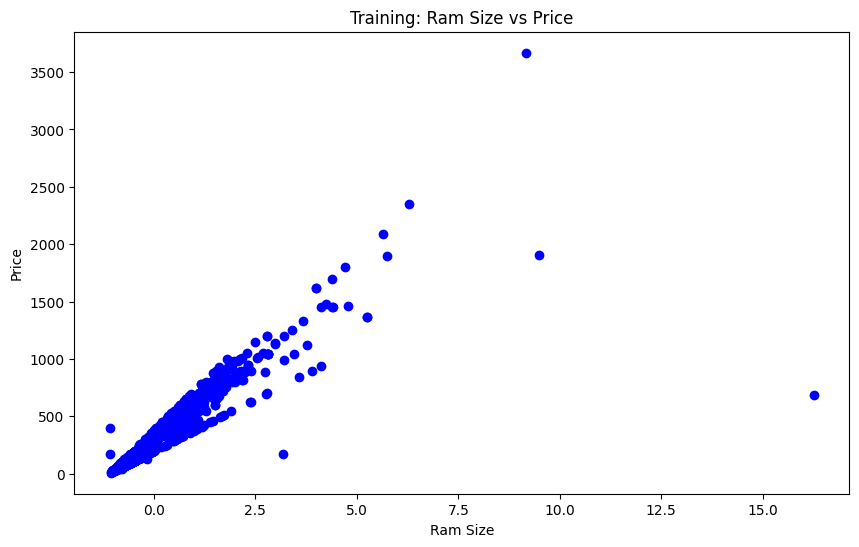

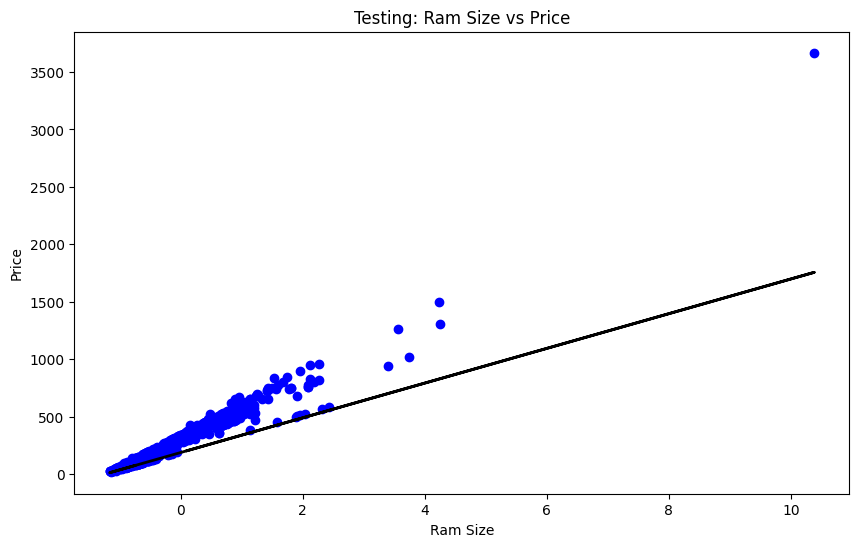

In [13]:
# Print the weights and bias of the model
weights = lin_model.weights
bias = lin_model.bias
print(f"Weights: {weights[:3]}, Bias: {bias}")
# print(f"Predictions: {lin_model.predict(xtest)[:3]}")

# Make predictions using the test set
ypred_line = lin_model.predict(xtest[[feature]])

# Visualise the predictions 
def visualise_regression(x, y, labels, ypred = None, title = "Training"):
    # Visualise the predictions using scatter plot

    if ypred is not None:
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, color="blue")
        plt.plot(x, ypred, color="black", linewidth=2)
        plt.xlabel(labels[0])
        plt.ylabel(labels[1])
        plt.title(f"{title}: {labels[0]} vs {labels[1]}")
    else:
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, color="blue")
        plt.xlabel(labels[0])
        plt.ylabel(labels[1])
        plt.title(f"{title}: {labels[0]} vs {labels[1]}")
    
    plt.show()

data_points = ["Ram Size", "Price"]
visualise_regression(xtrain[[feature]], ytrain, data_points)
visualise_regression(xtest[[feature]], ytest, data_points,  ypred_line, title="Testing")

## Model Evaluation

Techniques for model evaluation
+ Evaluation Metrics
+ Hyperparameter Tuning

In [14]:
# Import dependencies for implementing evaluation metrics 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

Evaluating models based on: 
+ 1 chosen input feature vs price price  
+ 2 input features vs laptop price
+ more than 2 input features vs laptop price 

In [15]:
# Evaluate: 1 chose feature vs price (Horsepower)
laptop_df.head()

,Price,Color,GPU,Processor Speed,Display Width,Display Height,OS,Storage Type,Hard Drive Capacity,SSD Capacity,Screen Size (cm),Ram Size,Price per Screen Size,Price per Display Height,Price per Display Width,Bluetooth,Touchscreen,WiFi,Webcam
0,400.00,black,intel,4.2,1920.0,1080.0,windows,ssd,2000.00,205.95,14.0,5.98,28.571429,0.370370,0.208333,Yes,No,Yes,Yes
1,175.00,black,intel,2.4,1920.0,1080.0,windows,ssd,500.00,500.00,14.0,16.00,12.500000,0.162037,0.091146,Yes,Yes,Yes,Yes
2,85.00,black,intel,2.4,1366.0,768.0,chrome,emmc,16.00,205.95,11.6,4.00,7.327586,0.110677,0.062225,Yes,No,Yes,Yes
3,101.25,other,other,1.4,1366.0,768.0,windows,ssd,98.89,256.00,12.5,8.00,8.100000,0.131836,0.074122,No,No,Yes,Yes
4,50.00,black,other,1.6,1366.0,768.0,chrome,ssd,98.89,16.00,11.6,4.00,4.310345,0.065104,0.036603,Yes,Yes,No,No


## Model Packaging

In [16]:
import joblib

In [17]:
# Save the linear regression model 
joblib.dump(lin_model, "linear_model1.pkl")

['linear_model1.pkl']